# Lecture 23 · Quantization round-trip & KV-cache memory

**Goal** · two short experiments behind efficient inference. **(a)** int8 *symmetric*
quantization of a weight tensor — compute the scale, quantize/dequantize, measure the
round-trip error, and see it shrink with **per-channel** scales. **(b)** size the
**KV-cache** with the lecture's formula and reproduce its worked numbers (a clean
512 MiB config, the exactly-2 GiB practice problem, and Llama-70B's ~10.5 GB), then plot
memory vs sequence length.

## Part (a) · int8 symmetric quantization

Symmetric int8 maps a real tensor to $\{-127,\dots,127\}$ with a single scale
$s=\dfrac{\max|w|}{127}$: quantize $q=\operatorname{round}(w/s)$, dequantize
$\hat w=q\cdot s$. First reproduce the lecture's worked example
$w=[1.2,\,-0.3,\,0.6,\,-2.0]$.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

def quantize_int8(w, scale):
    q = torch.clamp(torch.round(w / scale), -127, 127).to(torch.int8)
    return q

def dequantize_int8(q, scale):
    return q.to(torch.float32) * scale

w = torch.tensor([1.2, -0.3, 0.6, -2.0])
s = w.abs().max() / 127
q = quantize_int8(w, s)
w_hat = dequantize_int8(q, s)

print(f"scale s = max|w|/127 = {s.item():.6f}   (lecture ~0.015748)")
print(f"int8 codes           = {q.tolist()}          (lecture [76, -19, 38, -127])")
print(f"dequantized w_hat[0]  = {w_hat[0].item():.4f}   (lecture ~1.1968)")
print(f"round-trip error[0]   = {(w[0] - w_hat[0]).abs().item():.4f}   (lecture ~0.003)")
print(f"note: the outlier -2.0 is exact by construction -> it sets the scale")

scale s = max|w|/127 = 0.015748   (lecture ~0.015748)
int8 codes           = [76, -19, 38, -127]          (lecture [76, -19, 38, -127])
dequantized w_hat[0]  = 1.1969   (lecture ~1.1968)
round-trip error[0]   = 0.0031   (lecture ~0.003)
note: the outlier -2.0 is exact by construction -> it sets the scale


### Per-tensor vs per-channel scales

A single **per-tensor** scale is hostage to the largest outlier: one big weight stretches
$s$ and coarsens everyone else. A **per-channel** scale (one $s$ per output row) lets each
row use its own range, so the outlier only hurts its own channel. We plant an outlier in
one row of a weight matrix and compare reconstruction error.

per-tensor  relative error: 1.0024e-01
per-channel relative error: 2.4753e-02
improvement factor        : 4.0x


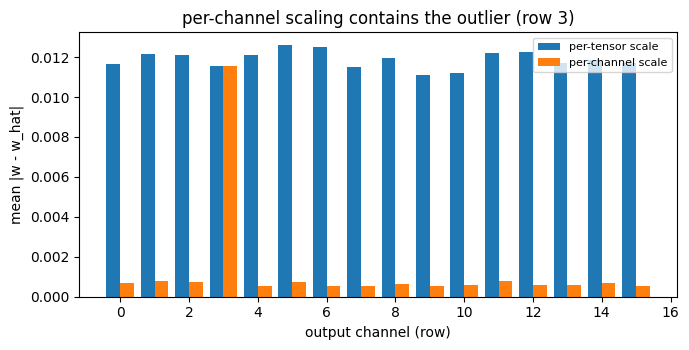

In [2]:
W = 0.1 * torch.randn(16, 256)      # (out_channels, in_channels)
W[3, 17] = 6.0                        # a single fat outlier in row 3

# --- per-tensor: one global scale ---
s_tensor = W.abs().max() / 127
W_hat_tensor = dequantize_int8(quantize_int8(W, s_tensor), s_tensor)

# --- per-channel: one scale per output row ---
s_chan = W.abs().amax(dim=1, keepdim=True) / 127          # shape (16, 1)
W_hat_chan = dequantize_int8(quantize_int8(W, s_chan), s_chan)

def rel_err(A, Ahat):
    return (A - Ahat).norm() / A.norm()

print(f"per-tensor  relative error: {rel_err(W, W_hat_tensor):.4e}")
print(f"per-channel relative error: {rel_err(W, W_hat_chan):.4e}")
print(f"improvement factor        : {rel_err(W, W_hat_tensor) / rel_err(W, W_hat_chan):.1f}x")

# per-row error to show the outlier's blast radius under per-tensor scaling
err_tensor = (W - W_hat_tensor).abs().mean(dim=1)
err_chan   = (W - W_hat_chan).abs().mean(dim=1)

plt.figure(figsize=(7, 3.6))
rows = np.arange(16)
plt.bar(rows - 0.2, err_tensor, width=0.4, label="per-tensor scale")
plt.bar(rows + 0.2, err_chan,   width=0.4, label="per-channel scale")
plt.xlabel("output channel (row)"); plt.ylabel("mean |w - w_hat|")
plt.title("per-channel scaling contains the outlier (row 3)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part (b) · KV-cache memory

Every decoded token must re-read the cached keys and values for the whole context. Its
size is

$$M = 2 \cdot L \cdot H_{\text{kv}} \cdot d_h \cdot T \cdot B \cdot \text{bytes},$$

with the leading $2$ for **K and V**. It scales **linearly** in every factor — which is
why long-context, large-batch decoding is a memory problem.

In [3]:
def kv_cache_bytes(L, H_kv, d_h, T, B, dtype_bytes):
    return 2 * L * H_kv * d_h * T * B * dtype_bytes

MiB = 2 ** 20
GiB = 2 ** 30

# clean 512 MiB config (BF16 = 2 bytes)
m = kv_cache_bytes(L=32, H_kv=8, d_h=128, T=4096, B=1, dtype_bytes=2)
print(f"[512 MiB config ] L=32 H_kv=8 d_h=128 T=4096 B=1 BF16 -> "
      f"{m:,} bytes = {m / MiB:.0f} MiB")

# lecture practice problem 2: exactly 2 GiB
m = kv_cache_bytes(L=32, H_kv=4, d_h=128, T=8192, B=4, dtype_bytes=2)
print(f"[practice prob 2] L=32 H_kv=4 d_h=128 T=8192 B=4 BF16 -> "
      f"{m:,} bytes = {m / GiB:.2f} GiB")

# lecture: Llama-70B at 32k context with GQA
m = kv_cache_bytes(L=80, H_kv=8, d_h=128, T=32000, B=1, dtype_bytes=2)
print(f"[Llama-70B GQA  ] L=80 H_kv=8 d_h=128 T=32k B=1 BF16 -> "
      f"{m / 1e9:.1f} GB (decimal)   (lecture ~10.5 GB)")

# same model with full MHA (64 KV heads): 8x larger
m_mha = kv_cache_bytes(L=80, H_kv=64, d_h=128, T=32000, B=1, dtype_bytes=2)
print(f"[Llama-70B MHA  ] H_kv=64 -> {m_mha / 1e9:.0f} GB  (GQA saves 64/8 = 8x)")

[512 MiB config ] L=32 H_kv=8 d_h=128 T=4096 B=1 BF16 -> 536,870,912 bytes = 512 MiB
[practice prob 2] L=32 H_kv=4 d_h=128 T=8192 B=4 BF16 -> 2,147,483,648 bytes = 2.00 GiB
[Llama-70B GQA  ] L=80 H_kv=8 d_h=128 T=32k B=1 BF16 -> 10.5 GB (decimal)   (lecture ~10.5 GB)
[Llama-70B MHA  ] H_kv=64 -> 84 GB  (GQA saves 64/8 = 8x)


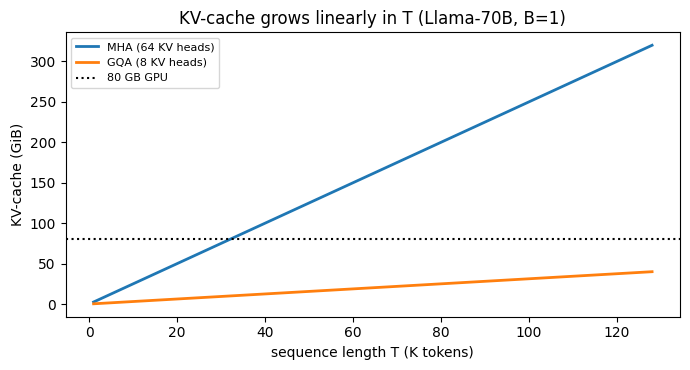

full MHA blows past an 80 GB GPU at ~33K tokens; GQA stays well under it


In [4]:
# Memory vs sequence length: GQA (H_kv=8) vs full MHA (H_kv=64) for the 70B config.
seqs = np.arange(1024, 128 * 1024 + 1, 1024)
mem_gqa = [kv_cache_bytes(80, 8,  128, T, 1, 2) / GiB for T in seqs]
mem_mha = [kv_cache_bytes(80, 64, 128, T, 1, 2) / GiB for T in seqs]

plt.figure(figsize=(7, 3.8))
plt.plot(seqs / 1024, mem_mha, lw=2, label="MHA (64 KV heads)")
plt.plot(seqs / 1024, mem_gqa, lw=2, label="GQA (8 KV heads)")
plt.axhline(80, color="k", ls=":", label="80 GB GPU")
plt.xlabel("sequence length T (K tokens)"); plt.ylabel("KV-cache (GiB)")
plt.title("KV-cache grows linearly in T (Llama-70B, B=1)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

t_cross = seqs[np.argmax(np.array(mem_mha) > 80)] / 1024
print(f"full MHA blows past an 80 GB GPU at ~{t_cross:.0f}K tokens; GQA stays well under it")

## Takeaway
- **Quantization** trades precision for memory and bandwidth: int8 halves (vs BF16) or
  quarters (vs FP32) the bytes streamed. A single per-tensor scale is wrecked by outliers;
  **per-channel** scales contain the damage — the first rung toward INT4 GPTQ/AWQ.
- The **KV-cache** dominates decode memory and scales linearly in
  $L,H_{\text{kv}},d_h,T,B$. That linear factor $H_{\text{kv}}$ is exactly what **GQA**
  shrinks ($8\times$ here), and long context is fundamentally a memory problem.